In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [9]:
import numpy as np
import pandas as pd
from collections import Counter

# numpy 사용

# 데이터셋 준비
data = {
    '기상예보': ['맑음','맑음','흐림','비','비','비','흐림','맑음','맑음','비','맑음','흐림','흐림','비'],
    '골프치기': ['N','N','Y','Y','Y','N','Y','N','Y','Y','Y','Y','Y','N']
}
df = pd.DataFrame(data)

# 라벨 인코딩
label_map = {'맑음': 0, '흐림': 1, '비': 2, 'N': 0, 'Y': 1}
df = df.replace(label_map)

# 엔트로피 계산 함수
def entropy(y):
    counts = np.bincount(y)
    probs = counts / len(y)
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

# 정보이득 계산
def information_gain(y, x):
    H_y = entropy(y)
    values = np.unique(x)
    weighted_entropy = 0

    for v in values:
        y_subset = y[x == v]
        weighted_entropy += (len(y_subset) / len(y)) * entropy(y_subset)

    return H_y - weighted_entropy

# 계산
gain = information_gain(df['골프치기'].values, df['기상예보'].values)
print(f"Gain(기상예보 기준): {gain:.4f}")


Gain(기상예보 기준): 0.2467


<ipython-input-9-7a717ca3e741>:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(label_map)


Accuracy: 1.00


/usr/local/lib/python3.11/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.11/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.11/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.11/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python3.11/dist-packages/sklearn/tree/_export.py:673: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  ann.update_bbox_position_size(renderer)
/usr/local/lib/python

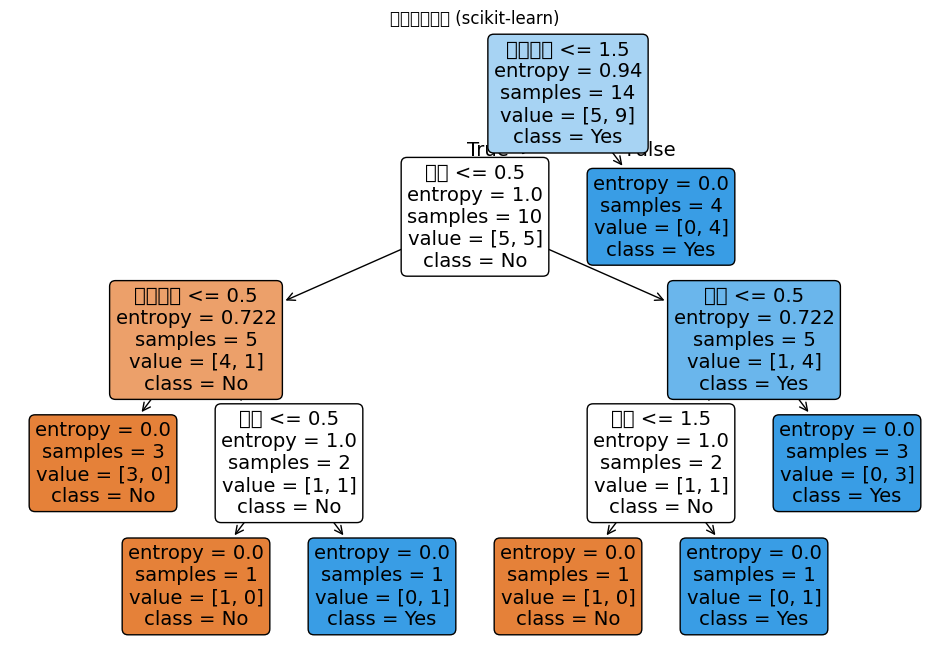

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Scikit-learn 사용

# 전체 데이터
full_data = {
    '날짜': ['D1','D2','D3','D4','D5','D6','D7','D8','D9','D10','D11','D12','D13','D14'],
    '기상예보': ['맑음','맑음','흐림','비','비','비','흐림','맑음','맑음','비','맑음','흐림','흐림','비'],
    '온도': ['고','고','고','중','저','저','저','중','저','중','중','중','고','중'],
    '습도': ['고','고','고','고','정상','정상','정상','고','정상','정상','정상','고','정상','고'],
    '바람': ['약','강','약','약','약','강','강','약','약','약','강','강','약','강'],
    '골프치기': ['N','N','Y','Y','Y','N','Y','N','Y','Y','Y','Y','Y','N']
}
df = pd.DataFrame(full_data).drop(columns=['날짜'])

# 인코딩
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=['골프치기'])
y = df['골프치기']

# 모델 학습
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

# 정확도
print(f"Accuracy: {clf.score(X, y):.2f}")

# 트리 시각화
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True)
plt.title("의사결정트리 (scikit-learn)")
plt.show()


Accuracy: 1.00


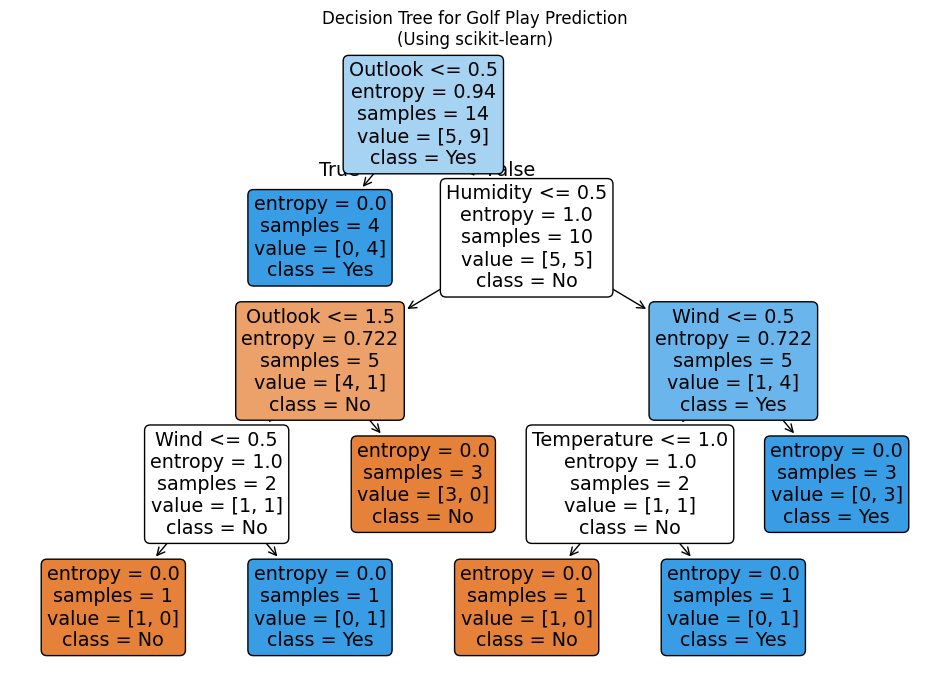

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Full dataset
data = {
    'Day': ['D1','D2','D3','D4','D5','D6','D7','D8','D9','D10','D11','D12','D13','D14'],
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayGolf': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}
df = pd.DataFrame(data)
df.drop(columns=['Day'], inplace=True)

# Label encoding
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=['PlayGolf'])
y = df['PlayGolf']

# Train model
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

# Accuracy
print(f"Accuracy: {clf.score(X, y):.2f}")

# Plot decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True)
plt.title("Decision Tree for Golf Play Prediction\n(Using scikit-learn)")
plt.show()


<ipython-input-17-69471953ac9e>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({'F': 2, 'M': 1})  # 성별 F=2, M=1로 변환
<ipython-input-17-69471953ac9e>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['BP'] = df['BP'].replace({'HIGH': 2, 'LOW': 1, 'NORMAL': 0})  # 혈압
<ipython-input-17-69471953ac9e>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the f

정확도: 1.00


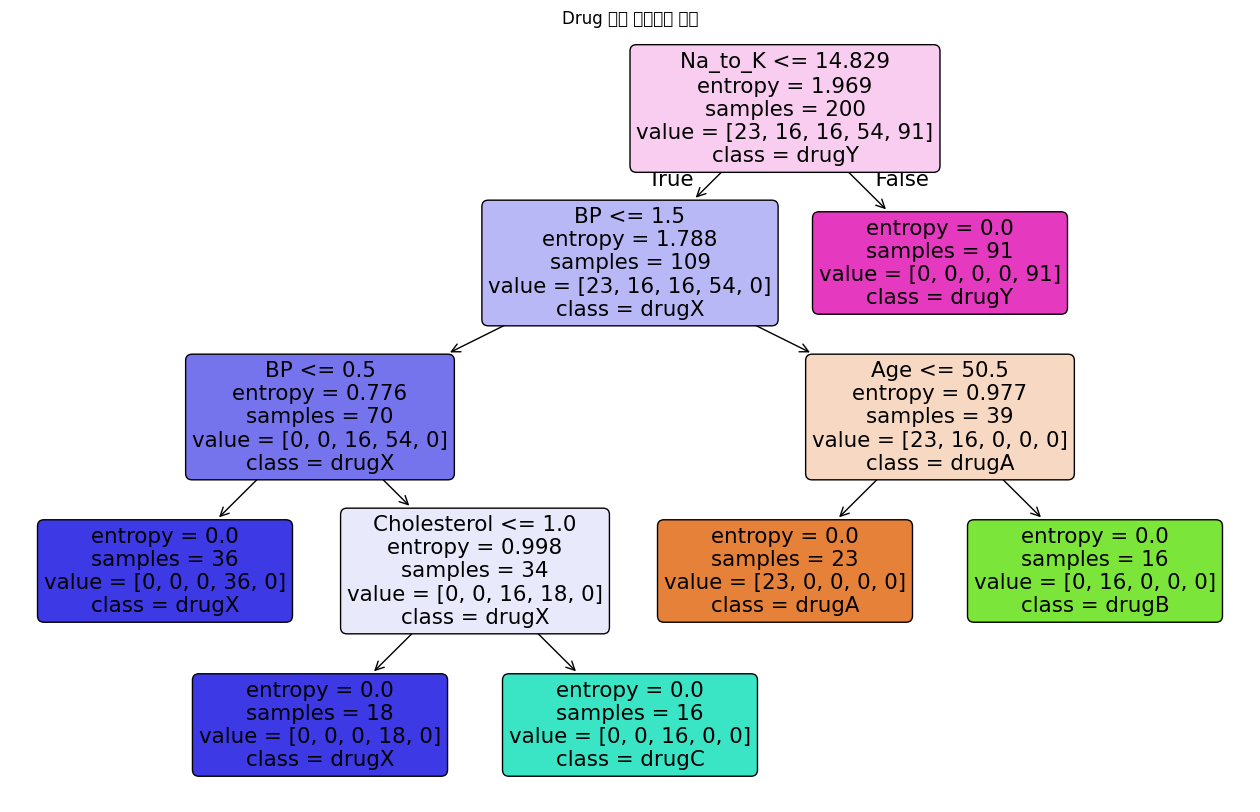

In [17]:
df = pd.read_csv('/content/drive/MyDrive/drug200.csv')

# 데이터 전처리
df['Sex'] = df['Sex'].replace({'F': 2, 'M': 1})  # 성별 F=2, M=1로 변환
df['BP'] = df['BP'].replace({'HIGH': 2, 'LOW': 1, 'NORMAL': 0})  # 혈압
df['Cholesterol'] = df['Cholesterol'].replace({'HIGH': 2, 'LOW': 1, 'NORMAL': 0})  # 콜레스테롤
df['Drug'] = df['Drug'].replace({'drugA': 1, 'drugB': 2, 'drugC': 3, 'drugX': 4, 'drugY': 5})  # 약 종류

# 입력(X), 출력(y) 설정
X = df.drop(columns=['Drug'])  # 특성
y = df['Drug']  # 라벨

# 의사결정 트리 모델 학습
clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

# 정확도 출력
print(f"정확도: {clf.score(X, y):.2f}")

# 의사결정 트리 시각화
plt.figure(figsize=(16, 10))
plot_tree(clf, feature_names=X.columns, class_names=['drugA','drugB','drugC','drugX','drugY'], filled=True, rounded=True)
plt.title("Drug 분류 의사결정 트리")
plt.show()
